# 🟢 Salary Survey Large Dataset (28,000+ rows)
## - Cleaning
## - EDA
## - Analysis
Ask A Manager Salary Survey 2021 (Responses) \
https://docs.google.com/spreadsheets/d/1IPS5dBSGtwYVbjsfbaMCYIWnOuRmJcbequohNxCyGVw/edit?resourcekey=&gid=1625408792#gid=1625408792

### Loading Data

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

os.makedirs("output", exist_ok=True)
os.makedirs("plots", exist_ok=True)

notebook_dir = os.path.abspath("")
dataset_path = os.path.join(notebook_dir, "data", "salary_survey.xlsx")
df = pd.read_excel(dataset_path)
df_org = df.copy()
df.sample(3)

,timestamp,age,industry,department,job_context,salary,bonus,currency,other_currency,income_context,country,us_state,city,overall_experience,field_experience,highest_education,gender,race
25169,2021-05-06 09:18:03.269,35-44,Government and Public Administration,Policy Analyst,NaN,141000,1500.0,USD,NaN,NaN,United States,District of Columbia,"Washington, DC",11 - 20 years,11 - 20 years,"Professional degree (MD, JD, etc.)",Woman,White
504,2021-04-27 11:10:57.979,35-44,Computing or Tech,Software Developer,NaN,92000,15000.0,CAD,NaN,NaN,Canada,NaN,Winnipeg,11 - 20 years,11 - 20 years,College degree,Man,White
3873,2021-04-27 12:18:43.542,45-54,Education (Higher Education),Instructional Designer,NaN,64671,0.0,USD,NaN,NaN,USA,Ohio,Columbus,11 - 20 years,11 - 20 years,College degree,Woman,White


# 🟢 EDA (Exploratory Data Analysis)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28221 entries, 0 to 28220
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   timestamp           28221 non-null  datetime64[us]
 1   age                 28221 non-null  str           
 2   industry            28135 non-null  str           
 3   department          28216 non-null  object        
 4   job_context         7293 non-null   object        
 5   salary              28221 non-null  int64         
 6   bonus               20848 non-null  float64       
 7   currency            28221 non-null  str           
 8   other_currency      222 non-null    object        
 9   income_context      3053 non-null   object        
 10  country             28219 non-null  object        
 11  us_state            23147 non-null  str           
 12  city                28136 non-null  object        
 13  overall_experience  28221 non-null  str           
 14  f

In [7]:
df.isna().sum()

timestamp                 0
age                       0
industry                 86
department                5
job_context           20928
salary                    0
bonus                  7373
currency                  0
other_currency        27999
income_context        25168
country                   2
us_state               5074
city                     85
overall_experience        0
field_experience          0
highest_education       241
gender                  186
race                    197
dtype: int64

In [8]:
df.columns

Index(['timestamp', 'age', 'industry', 'department', 'job_context', 'salary',
       'bonus', 'currency', 'other_currency', 'income_context', 'country',
       'us_state', 'city', 'overall_experience', 'field_experience',
       'highest_education', 'gender', 'race'],
      dtype='str')

In [9]:
df.sample(4)

,timestamp,age,industry,department,job_context,salary,bonus,currency,other_currency,income_context,country,us_state,city,overall_experience,field_experience,highest_education,gender,race
4781,2021-04-27 12:46:53.101,25-34,Libraries,Public Services Supervisor,NaN,64341,0.0,USD,NaN,NaN,USA,Virginia,Richmond,8 - 10 years,8 - 10 years,Master's degree,Woman,White
3244,2021-04-27 12:02:07.503,25-34,Corporate sustainability,Policy Analyst,NaN,86000,0.0,USD,NaN,NaN,United States,District of Columbia,Washington,2 - 4 years,2 - 4 years,College degree,Woman,White
2613,2021-04-27 11:48:20.391,45-54,Education (Primary/Secondary),Teacher - Grade 6,NaN,95000,0.0,CAD,NaN,You'd multiply by about 0.70 to get the amount...,Canada,NaN,St Thomas,31 - 40 years,11 - 20 years,College degree,Woman,White
23276,2021-05-01 23:49:19.492,25-34,Computing or Tech,Technical Writer,NaN,47840,NaN,USD,NaN,NaN,United States,Missouri,Kansas City,8 - 10 years,8 - 10 years,College degree,Woman,White


checking unique values along with their counts

In [10]:
print(df.country.value_counts(),'\n')
print(df.age.value_counts(), '\n')
print(df.currency.value_counts(), '\n')
print(df.gender.value_counts(), '\n')
print(df.race.value_counts(), '\n')

country
United States     9036
USA               7963
US                2620
Canada            1576
United States      669
                  ... 
Thailand             1
Liberia              1
1                    1
Nigeria + UK         1
Zambia               1
Name: count, Length: 390, dtype: int64 

age
25-34         12704
35-44          9915
45-54          3196
18-24          1295
55-64           998
65 or over       95
under 18         18
Name: count, dtype: int64 

currency
USD        23496
CAD         1677
GBP         1597
EUR          654
AUD/NZD      505
Other        174
CHF           37
SEK           37
JPY           23
ZAR           17
HKD            4
Name: count, dtype: int64 

gender
Woman                            21427
Man                               5562
Non-binary                         747
Other or prefer not to answer      298
Prefer not to answer                 1
Name: count, dtype: int64 

race
White                                                              

Detecting outliers in salary data

In [11]:
# this function will save plots automatically, without needing to write the long code each time
def save_figure(name):
    plt.savefig(os.path.join(notebook_dir, f"plots/{name}.png"), dpi=300, bbox_inches="tight")

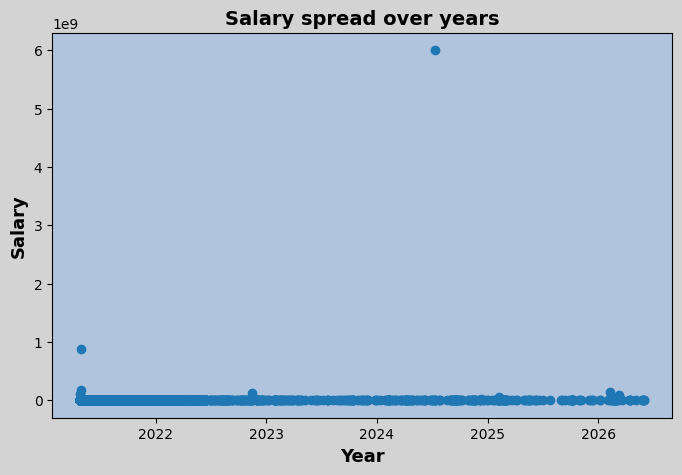

In [ ]:
plt.figure(figsize=(8, 5), facecolor='lightgray')
plt.gca().set_facecolor('lightsteelblue')
plt.scatter(df.timestamp, df.salary)
plt.xlabel("Year", fontweight='bold', fontsize=13)
plt.ylabel("Salary", fontweight='bold', fontsize=13)
plt.title("Salary spread over years", fontweight='bold', fontsize=14)
plt.show()

# 🟢 Data Cleaning

### Dropping unnecessary columns

In [13]:
df.reset_index(drop=True)
df.drop(['job_context', 'other_currency', 'income_context', 'overall_experience'], axis=1, inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28221 entries, 0 to 28220
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   timestamp          28221 non-null  datetime64[us]
 1   age                28221 non-null  str           
 2   industry           28135 non-null  str           
 3   department         28216 non-null  object        
 4   salary             28221 non-null  int64         
 5   bonus              20848 non-null  float64       
 6   currency           28221 non-null  str           
 7   country            28219 non-null  object        
 8   us_state           23147 non-null  str           
 9   city               28136 non-null  object        
 10  field_experience   28221 non-null  str           
 11  highest_education  27980 non-null  str           
 12  gender             28035 non-null  str           
 13  race               28024 non-null  str           
dtypes: datetime64[us]

### Fixing 'age' column

In [14]:
df['age'] = df['age'].replace({'under 18':'<18', '65 or over':'65+'})
df.age.unique()

<StringArray>
['25-34', '45-54', '35-44', '18-24', '65+', '55-64', '<18']
Length: 7, dtype: str

### Fixing 'industry' column
(many entries have more than 60 characters, we'd just pick initial 3 words...most of them contain the industry titles at the start)

In [15]:
# # this handles the first 3 words of the entries after converting them to strings and splitting based on [{commas}] and [{spaces}] 
df['industry'] = (df['industry']
 .astype(str)
 .str.strip()   # removing whitespaces
 .str.split(r',|\s+')   # splitting based on commas or whitespaces
 .apply(lambda x: " ".join(x[:3]) if isinstance(x, list) else x)   # obtaining & joining first 3 words
 .str.title()       # title format
 )

# value counts of top 10 industries
df.industry.value_counts()[:10]

industry
Computing Or Tech               4724
Education (Higher Education)    2480
Nonprofits                      2421
Health Care                     1905
Government And Public           1894
Accounting  Banking             1823
Engineering Or Manufacturing    1709
Marketing  Advertising          1137
Law                             1101
Business Or Consulting           858
Name: count, dtype: int64

### Fixing 'department' the same way

In [16]:
# # this handles the first 3 words of the entries after converting them to strings and splitting based on [{commas}] and [{spaces}] 
df['department'] = (df['department']
 .astype(str)
 .str.strip()   # removing whitespaces
 .str.split(r',|\s+')   # splitting based on commas or whitespaces
 .apply(lambda x: " ".join(x[:3]) if isinstance(x, list) else x)   # obtaining & joining first 3 words
 .str.title()       # title format
 )

# value counts of top 10 departments
df.department.value_counts()[:10]

department
Software Engineer           393
Project Manager             295
Senior Software Engineer    256
Director                    223
Executive Assistant         205
Program Manager             200
Teacher                     177
Librarian                   167
Manager                     163
Administrative Assistant    152
Name: count, dtype: int64

### Fixing 'country' column 
(handled duplicates, spelling errors, sentences, non-uniform country names)

In [17]:
country_groups = {
    'United States': ['united states', 'us', 'usa', 'u.s.a', 'united state', 'united states of america', 'u.s', 'u.s.', 'u.s.a.', 'america', 'unites states', 'united stated', 'the united states', 'u. s.', 'united sates', 'united state of america', 'united stares', 'unitedstates', '🇺🇸', 'isa', 'united statea', 'united states of american', 'united sates of america', 'united status', 'i.s.', 'unite states', 'the us', 'usa tomorrow'],
    'United Kingdom': ['united kingdom', 'uk', 'u.k.', 'england', 'britain', 'great britain', 'england, uk', 'northern ireland', 'england, united kingdom', 'scotland, uk', 'united kingdom (england)', 'uk (england)'],
    'United Arab Emirates': ['united arab emirates', 'uae', 'u.a.e'],
    'hong kong': ['hong kongkong'],
    'netherlands': ['the netherlands'],
    'new zealand': ['nz'],
    'canada': ['canda']
}

mapping_dict = {variant: correct_name 
                for correct_name, variants in country_groups.items() 
                for variant in variants}

df['country'] = (df['country']
 .astype(str)
 .str.lower()
 .str.strip()
 .str.replace(r'\d*', '', regex=True)
 .replace('', np.nan)
 .replace(mapping_dict)
 .str.title()
 )

df['country'] = df['country'].mask(df['country'].map(df['country'].value_counts()) < 2)
df.country.value_counts()[-10:]

country
Remote       2
Lithuania    2
Indonesia    2
Slovenia     2
Bulgaria     2
Estonia      2
Morocco      2
Zimbabwe     2
Croatia      2
Cyprus       2
Name: count, dtype: int64

### Fixing 'us_state' column
(a lot of entries had 2+ states listed, those were removed, their value counts were also lower than 5)

In [18]:
# the entries with value_counts from 6-1 were only gibberish and the rest were okay...those are removed

df['us_state'] = (df['us_state']
                  .mask(df['us_state'].map(df['us_state'].value_counts()) < 7)
                  .str.strip()
                  .str.title())
df.us_state.value_counts()[:10]

us_state
California              2616
New York                2180
Massachusetts           1523
Texas                   1271
Illinois                1213
Washington              1185
District Of Columbia     983
Pennsylvania             946
Virginia                 786
Minnesota                723
Name: count, dtype: int64

### Fixing 'city' column
(turning invalid entries into nan)

In [19]:
df['city'] = (df['city']
              .mask(df['city'].map(df['city'].value_counts()) <= 2)
              .str.strip()
              .str.title())


print("Top 10 Cities:\n", df.city.value_counts()[:10], "\n\nChecking length of entries (if they exceed 30+ char)")
df.city[df.city.str.len() > 24][:15]        # asked for 15 but it shows only a few, it means char lengths are also fixed now (by removing teh gibberish)

Top 10 Cities:
 city
Chicago          831
Boston           829
New York         815
Seattle          743
London           626
San Francisco    589
Los Angeles      537
New York City    529
Portland         485
Toronto          444
Name: count, dtype: int64 

Checking length of entries (if they exceed 30+ char)


10424    Vancouver, British Columbia
13084    Vancouver, British Columbia
13324    Vancouver, British Columbia
16530    Vancouver, British Columbia
16538    Vancouver, British Columbia
19235      Adelaide, South Australia
19243      Adelaide, South Australia
19252      Adelaide, South Australia
Name: city, dtype: object

### Fixing 'field_experience' column 
(converting [y - y], [y-y], [y] formats of year brackets into raw digits and then obtaining the average of the years)

In [20]:
df.field_experience.unique()    # checking all unique experience brackets

<StringArray>
[       '5-7 years',      '2 - 4 years',    '21 - 30 years',
    '11 - 20 years',   '1 year or less',     '8 - 10 years',
    '31 - 40 years', '41 years or more']
Length: 8, dtype: str

In [21]:
# stripping the unnecessary text from it
df['field_experience'] = df['field_experience'].str.strip(' yearsmoreless')
df.field_experience.unique()    # checking the output

# defining a function which extracts the digits and calculates their averages across entire column
def get_xp(years):
    if pd.notna(years):     # taking only valid values (other than NaN)
        yr = re.split(r' - |-', years)      # splitting based on the pattern we have (-) or ( - )
        if len(yr) > 1:     # if length of the yr variable is greater than 1, meaning, if there is 2 individual entitites, then the code below will be executed
            avg_xp = (int(yr[0]) + int(yr[1]))/2        # picks each year entity from the list, then turn it into integer and calculate average
            return avg_xp           # the year bracket converted into average is returned
        return yr[0]            # if there was no year bracket and only a single digit(s), it would be returned
    return years            # this is what it returns if no above condition is met, basically the NaN values

df['field_experience'] = df['field_experience'].astype(str).apply(get_xp).astype(float)   # applying the function
df.rename(columns={"field_experience": "avg_experience"}, inplace=True)     # renaming the column
df.avg_experience.sample(5)

15687     3.0
12958    15.5
24142     6.0
21437     6.0
22730     1.0
Name: avg_experience, dtype: float64

### Fixing a long education title in 'highest_education' column

In [22]:
df['highest_education'] = df['highest_education'].replace({'Professional degree (MD, JD, etc.)': 'Professional degree'})

df.highest_education.value_counts()

highest_education
College degree         13568
Master's degree         8899
Some college            2097
PhD                     1428
Professional degree     1329
High School              659
Name: count, dtype: int64

### Fixing long entries of 'gender' column into shorter, professional ones

In [23]:
df.gender.unique()

<StringArray>
[                        'Woman',                    'Non-binary',
                           'Man',                             nan,
 'Other or prefer not to answer',          'Prefer not to answer']
Length: 6, dtype: str

In [24]:
df['gender'] = df['gender'].replace({'Man':'Male', 'Woman':'Female', 'Other or prefer not to answer':'Other', 'Prefer not to answer':'Other'})
df.gender.unique()

<StringArray>
['Female', 'Non-binary', 'Male', nan, 'Other']
Length: 5, dtype: str

### Fixing the 'race' column 
it has several gibberish and mixed up entries exceeding the character size of 50-70

In [25]:
df.race.value_counts()[:4]

race
White                                                     23274
Asian or Asian American                                    1431
Black or African American                                   707
Another option not listed here or prefer not to answer      630
Name: count, dtype: int64

In [26]:
# this method takes the initial 9 letters of each entry and then cleans them to obtain proper race for each entry

df['race'] = df['race'].apply(
    lambda x: x[:9] if pd.notna(x) else x)
df['race'] = df['race'].str.split(r',| ').str[0]
df['race'] = df['race'].replace({'Another':'Other', 'Middle':'Middle Eastern', 'Native':'Native American'})
df.race.value_counts(dropna=False)

race
White              23339
Asian               1857
Hispanic            1034
Black                889
Other                630
NaN                  197
Middle Eastern       161
Native American      114
Name: count, dtype: int64

### Handling missing values (NaN)

In [27]:
df.isna().sum()

timestamp               0
age                     0
industry               86
department              5
salary                  0
bonus                7373
currency                0
country               160
us_state             5188
city                 4469
avg_experience          0
highest_education     241
gender                186
race                  197
dtype: int64

In [28]:
# dropping the rows with either highly important or unnecessary or negligibly low missing data
df.dropna(subset=['industry', 'department', 'country', 'highest_education'], inplace=True)

# filling the missing rows of some columns appropriately
df.fillna({"bonus":"No Bonus", "us_state":"N/A", "city":"N/A"}, inplace=True)
df['bonus'] = df['bonus'].replace({0: "No Bonus"})

# filling the gender and race columns' missing values with their previous values using mode
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])
df['race'] = df['race'].fillna(df['race'].mode()[0])

df.isna().sum()

timestamp            0
age                  0
industry             0
department           0
salary               0
bonus                0
currency             0
country              0
us_state             0
city                 0
avg_experience       0
highest_education    0
gender               0
race                 0
dtype: int64

## saving cleaned dataset

In [29]:
with pd.ExcelWriter(os.path.join(notebook_dir, "output", "clean_survey.xlsx")) as writer:
    df.to_excel(writer, sheet_name="Clean", index=False)
    df_org.to_excel(writer, sheet_name="Dirty", index=False)

df.sample(5)

,timestamp,age,industry,department,salary,bonus,currency,country,us_state,city,avg_experience,highest_education,gender,race
25708,2021-05-07 15:47:57.715,35-44,Sales,Vp Of Sales,200000,210000.0,USD,United States,Massachusetts,Boston,15.5,College degree,Male,White
1332,2021-04-27 11:23:59.423,25-34,Business Or Consulting,Senior Consultant,86000,No Bonus,USD,United States,District Of Columbia,Washington D.C.,9.0,College degree,Female,White
19374,2021-04-29 09:17:29.106,55-64,Nonprofits,For Of Hr,97000,No Bonus,USD,United States,Montana,N/A,25.5,Master's degree,Female,White
10362,2021-04-27 20:40:16.342,35-44,Nonprofits,Executive Director,0,No Bonus,USD,United States,North Dakota,Charlotte,15.5,Master's degree,Other,White
15341,2021-04-28 17:03:42.736,18-24,Education (Higher Education),Phd Student,72000,No Bonus,CHF,Switzerland,N/A,N/A,3.0,Master's degree,Non-binary,White


# 🟢 Data Analysis

In [30]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [31]:
df = pd.read_excel(os.path.join(notebook_dir, "output", "clean_survey.xlsx"))
df.sample(4)

,timestamp,age,industry,department,salary,bonus,currency,country,us_state,city,avg_experience,highest_education,gender,race
16788,2021-04-28 19:13:03.882,25-34,Biotech/Drug Development,Nonclinical Manager,90000,7000,USD,United States,Massachusetts,"Cambridge, Ma",9.0,College degree,Female,White
16421,2021-04-28 18:19:33.187,45-54,Accounting Banking,Team Leader,84000,10000,USD,United States,Arizona,Tempe,15.5,Some college,Male,White
8042,2021-04-27 15:39:42.893,18-24,Computing Or Tech,Software Engineer,103600,40000,USD,United States,California,Santa Barbara,3.0,Some college,Female,White
1274,2021-04-27 11:23:12.527,35-44,Computing Or Tech,Associate Director Of,210000,100000,USD,United States,Washington,Seattle,15.5,Master's degree,Female,White


## Q.1 Which industry pays the most?

Before this, the standard salary column must be created to convert all currencies into USD

In [32]:
# dropping all rows with 'Other' currency
df = df.drop(df[df['currency'] == 'Other'].index)

# dropping all industry columns with extremely less value counts (as they skew the data so much)
df = df[df.groupby('industry')['industry'].transform('count') >= 6]

# map for all currencies for converting them into USD
currency_map = {
    "USD": 1.00,
    "GBP": 1.34,
    "CAD": 0.72,
    "EUR": 1.16,
    "AUD": 0.71,
    "CHF": 1.26,
    "ZAR": 0.06,
    "SEK": 0.11,
    "HKD": 0.13,
    "JPY": 0.006,
    "AUD/NZD": 1.21,
}

df['currency_value'] = df['currency'].map(currency_map)
df['usd_salary'] = df['salary'] * df['currency_value']

# this sample shows 5 rows illustrating the change after the previous cell's alteration
sample = df[['salary', 'currency', 'currency_value', 'usd_salary']]
# it only shows the sample with currencies other than USD to better understand
sample[sample['currency'] != "USD"].sample(5)

,salary,currency,currency_value,usd_salary
25703,132000,CAD,0.72,95040.0
13976,48000,GBP,1.34,64320.0
19860,23000,GBP,1.34,30820.0
9827,135000,CAD,0.72,97200.0
20974,52000,GBP,1.34,69680.0


Identifying and removing outliers

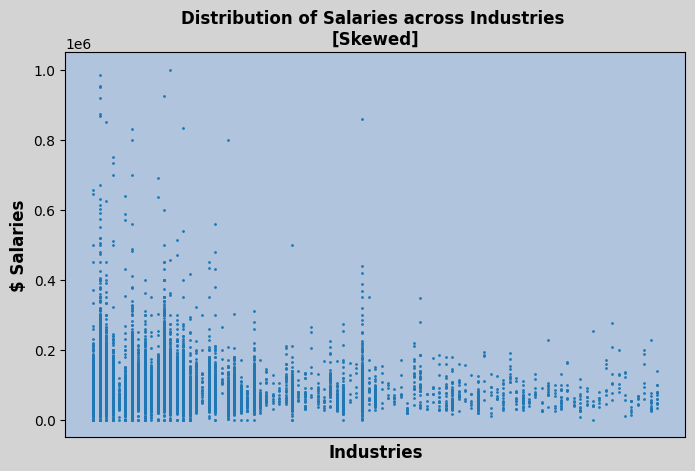

In [33]:
df = df[df['usd_salary'] <= 1000000]        # we must remove the extreme outliers which skews the plot insanely...

# here we have the readable outliers
plt.figure(figsize=(8,5), facecolor='lightgray')
plt.gca().set_facecolor('lightsteelblue')
plt.scatter(df['industry'], df['usd_salary'], s=1)
plt.title("Distribution of Salaries across Industries \n[Skewed]", fontweight='bold')
plt.ylabel("$ Salaries", fontsize=12, fontweight='bold')
plt.xlabel("Industries", fontsize=12, fontweight='bold')
plt.xticks([])
plt.show()

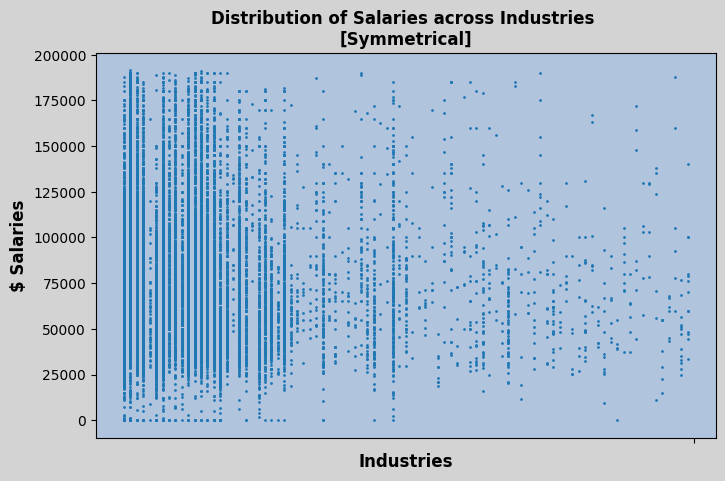

In [34]:
q1 = df['usd_salary'].quantile(0.25)
q3 = df['usd_salary'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

df = df[(df['usd_salary'] >= lower_bound) & (df['usd_salary'] <= upper_bound)]


plt.figure(figsize=(8, 5), facecolor='lightgray')
plt.gca().set_facecolor('lightsteelblue')
plt.scatter(df['industry'], df['usd_salary'], s=1)
plt.title("Distribution of Salaries across Industries \n[Symmetrical]", fontweight='bold')
plt.ylabel("$ Salaries", fontsize=12, fontweight='bold')
plt.xlabel("Industries", fontsize=12, fontweight='bold')
plt.xticks([''], fontsize=12)
save_figure("salary_distribution_in_industries")
plt.show()

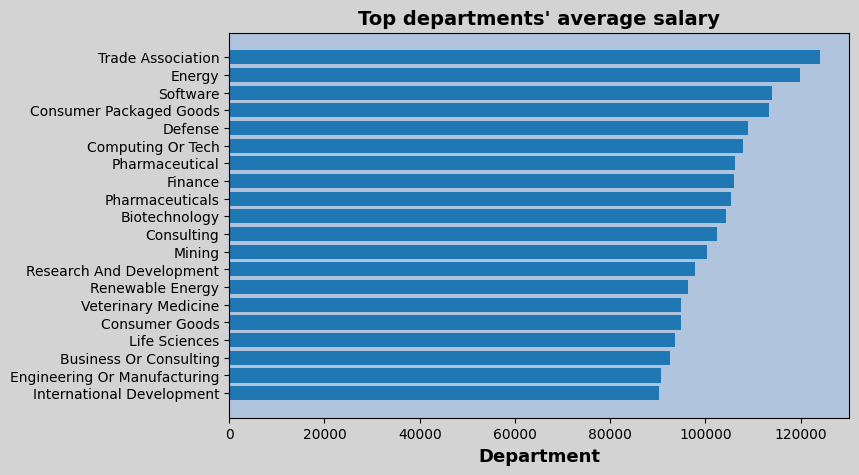

In [35]:
df['industry'] = df['industry'].replace({'Bitech': 'Biotechnology', 
                                         'Biotech / Pharmaceutical': 'Biotechnology', 
                                         'Biotech Industry': 'Biotechnology', 
                                         'Pharmaceuticals / Biotech': 'Biotechnology',
                                         'Pharmaceutical/Biotech': 'Biotechnology',
                                         'Pharma/Biotech': 'Biotechnology',
                                         'Biotech/Pharma': 'Biotechnology',
                                         'Biotech':'Biotechnology',
                                         'Pharmaceutical Company': 'Pharmaceuticals',
                                         'Pharma': 'Pharmaceuticals',
                                         'Pharma/ Research': 'Pharma / Research',
                                         'Pharma Research': 'Pharma / Research',
                                         'Pharma R&D': 'Pharma Research'
                                         })
gb = df.groupby('industry')['usd_salary'].mean().sort_values()[-20:]

plt.figure(figsize=(8, 5), facecolor='lightgray')
plt.gca().set_facecolor('lightsteelblue')
plt.barh(gb.index, gb.values)
plt.xlabel("Salary (USD)", fontweight='bold', fontsize=13)
plt.xlabel("Department", fontweight='bold', fontsize=13)
plt.title("Top departments' average salary", fontweight='bold', fontsize=14)
save_figure("top_dept_avg_salary_barh")
plt.show()

In [36]:
print("Here are Top 10 industries with the highest salaries with:\n", *gb[-1:].index, "ranking at #1 having average salary of", *gb[-1:].values, "USD")
gb[-10:][::-1].round(2)

Here are Top 10 industries with the highest salaries with:
 Trade Association ranking at #1 having average salary of 124000.0 USD


industry
Trade Association          124000.00
Energy                     119927.18
Software                   113950.00
Consumer Packaged Goods    113286.00
Defense                    109024.71
Computing Or Tech          107820.76
Pharmaceutical             106182.97
Finance                    106096.00
Pharmaceuticals            105474.48
Biotechnology              104236.83
Name: usd_salary, dtype: float64

## Q.2 How does salary increase given years of experience?

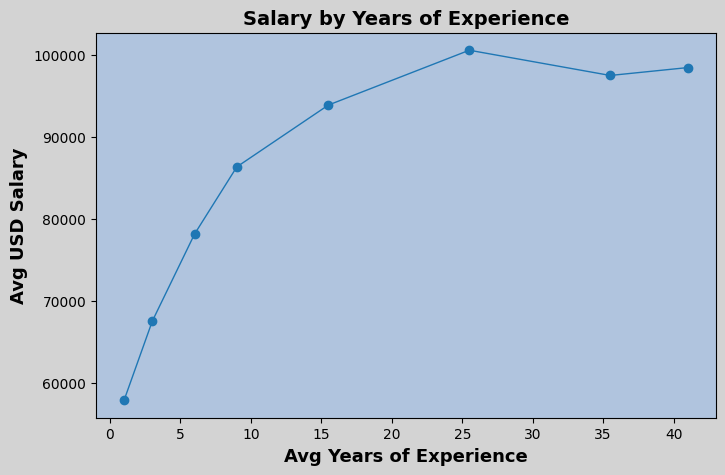

In [37]:
gb = df.groupby(['avg_experience'])["usd_salary"].mean().round()
gb = gb.sort_index()  # make sure x goes 0.5 → 3 → 7.5 → 15 → 22.5

plt.figure(figsize=(8, 5), facecolor='lightgray')
plt.gca().set_facecolor('lightsteelblue')
plt.plot(gb.index, gb.values, marker='o', linewidth=1)
plt.xlabel("Avg Years of Experience", fontweight='bold', fontsize=13)
plt.ylabel("Avg USD Salary", fontweight='bold', fontsize=13)
plt.title("Salary by Years of Experience", fontweight='bold', fontsize=14)
save_figure("salary_experience_plot")
plt.show()

In [38]:
xx = gb.values.max()
print("People with", *gb[gb==gb.max()].index, f"years of average experience get the highest salaries with an average amount of {gb.values.max()} USD.\nBut the salaries generally increase with the increase in experience.")
gb

People with 25.5 years of average experience get the highest salaries with an average amount of 100528.0 USD.
But the salaries generally increase with the increase in experience.


avg_experience
1.0      57901.0
3.0      67521.0
6.0      78134.0
9.0      86319.0
15.5     93851.0
25.5    100528.0
35.5     97454.0
41.0     98413.0
Name: usd_salary, dtype: float64

## Q.3 How do salaries compare for the same role in different locations?

In [39]:
df = df[df.groupby('department')['department'].transform('count') >= 11]    # removing the rows of department with valuecounts less than 10
gb = df.groupby(['country', 'department'])['usd_salary'].mean()
gb

country        department              
Australia      Accountant                   94380.000000
               Admin Assistant              63525.000000
               Administrative Assistant     90750.000000
               Architect                   108900.000000
               Assistant Director          137335.000000
                                               ...      
United States  Writer                       49633.166667
               Youth Services Librarian     49312.666667
Vietnam        Reference Librarian          21600.000000
Wales          Engineering Manager         103180.000000
Zimbabwe       Manager                      20000.000000
Name: usd_salary, Length: 1009, dtype: float64

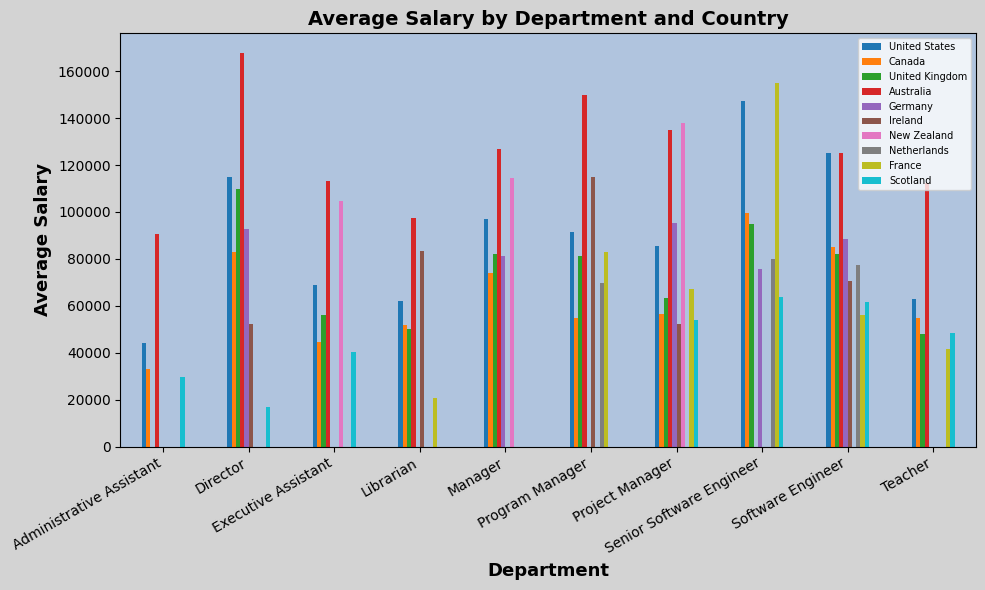

In [40]:
# picking top 10 countries and top 10 departments
top_countries = df['country'].value_counts().index[:10]
top_depts  = df['department'].value_counts().index[:10]

filtered = df[df['country'].isin(top_countries) & df['department'].isin(top_depts)]
pivot = filtered.groupby(['department', 'country'])['usd_salary'].mean().unstack('country', sort=False)
pivot = pivot[top_countries]

fig, ax = plt.subplots(figsize=(10, 6), facecolor='lightgray')
pivot.plot(kind='bar', ax=ax)
ax.set_facecolor('lightsteelblue')
plt.xlabel("Department", fontweight='bold', fontsize=13)
plt.ylabel("Average Salary", fontweight='bold', fontsize=13)
plt.title("Average Salary by Department and Country", fontweight='bold', fontsize=14)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.legend(fontsize=7)
save_figure("avg_salary_dept_country")
plt.show()


In [41]:
# Overall highest paying country (mean across all depts)
country_avg = pivot.mean(axis=0, numeric_only=True).sort_values(ascending=False).round()
print(country_avg)

# Which country pays most per department (column-wise)
pivot['top_country'] = pivot.idxmax(axis=1, numeric_only=True)
pivot['top_salary'] = pivot.max(axis=1, numeric_only=True)
print(pivot[['top_country', 'top_salary']])

# Rank countries by how often they're the top payer
top_counts = pivot.idxmax(axis=1, numeric_only=True).value_counts()
print(top_counts)
print(f"{top_counts.index[0]} stands at the top for the most high paying country followed by {top_counts.index[1]}, {top_counts.index[2]}, {top_counts.index[3]}")

country
Australia         124288.0
New Zealand       118983.0
United States      89952.0
Germany            86633.0
Netherlands        75664.0
Ireland            74762.0
United Kingdom     74120.0
France             70648.0
Canada             63697.0
Scotland           44867.0
dtype: float64
country                     top_country     top_salary
department                                            
Administrative Assistant      Australia   90750.000000
Director                      Australia  167786.666667
Executive Assistant           Australia  113217.038000
Librarian                     Australia   97405.000000
Manager                       Australia  127050.000000
Program Manager               Australia  150040.000000
Project Manager             New Zealand  137940.000000
Senior Software Engineer         France  155000.000000
Software Engineer         United States  125167.906716
Teacher                       Australia  112189.385000
Australia        7
New Zealand      1
France   

## Q.4 How much do salaries differ by gender and years of experience?

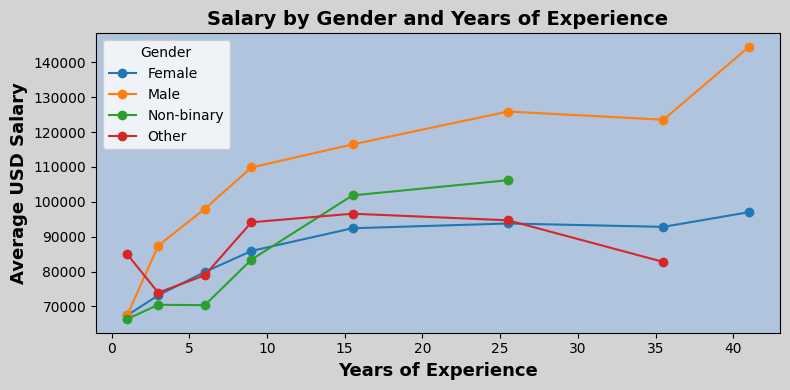

In [42]:
gb = df.groupby(['gender', 'avg_experience'])['usd_salary'].mean()
gb = gb.reset_index()

fig, ax = plt.subplots(figsize=(8, 4), facecolor='lightgray')
ax.set_facecolor('lightsteelblue')

gb.pivot(index='avg_experience', columns='gender', values='usd_salary').plot(marker='o', ax=ax)

ax.set_title('Salary by Gender and Years of Experience', fontweight='bold', fontsize=14)
ax.set_xlabel('Years of Experience', fontweight='bold', fontsize=13)
ax.set_ylabel('Average USD Salary', fontweight='bold', fontsize=13)
ax.legend(title='Gender')
plt.tight_layout()
save_figure("salary_gender_experience_plot")
plt.show()

In [43]:
print("Insight: Male salaries nearly double with experience, while Female and Non-binary grow moderately. Other peaks mid-career then declines. The gender pay gap widens heavily after 3 years of experience.")

Insight: Male salaries nearly double with experience, while Female and Non-binary grow moderately. Other peaks mid-career then declines. The gender pay gap widens heavily after 3 years of experience.


## Q.5 How do factors like race and education level correlate with salary?

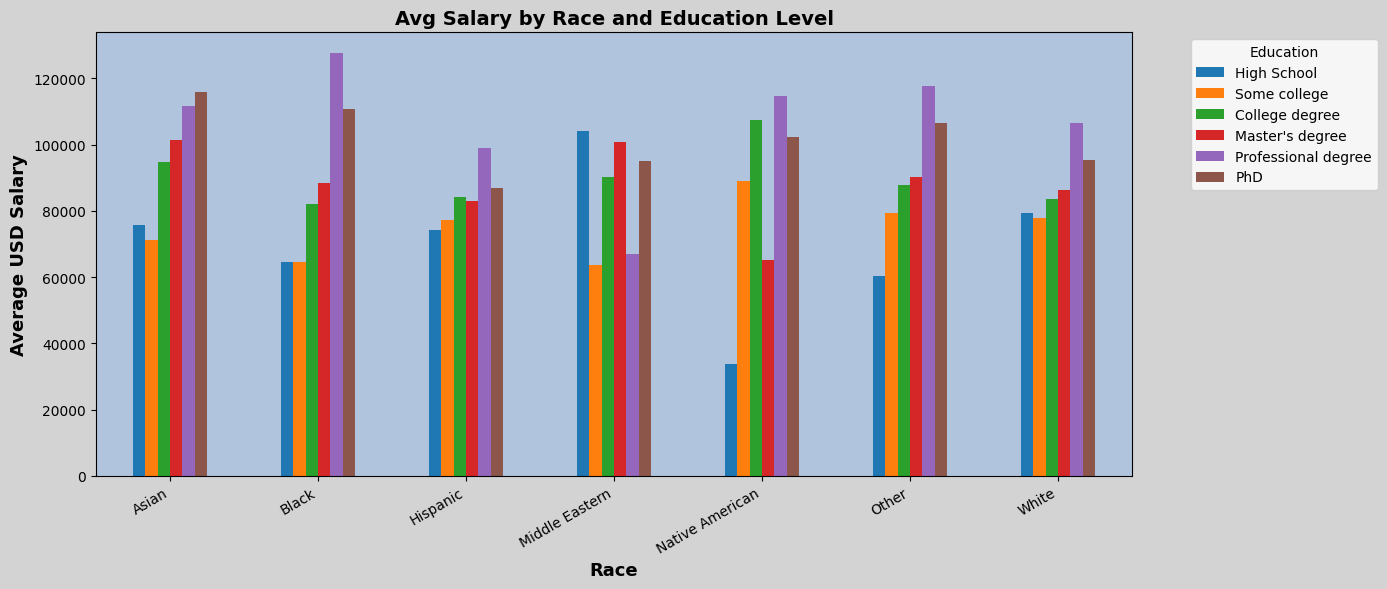

In [44]:
# fix education order
edu_order = ['High School', 'Some college', 'College degree', "Master's degree", 'Professional degree', 'PhD']

fig, ax = plt.subplots(figsize=(14, 6), facecolor='lightgray')
df.groupby(['race', 'highest_education'])['usd_salary'].mean().unstack('highest_education')[edu_order].plot(kind='bar', ax=ax)
ax.set_facecolor('lightsteelblue')
plt.xlabel('Race', fontweight='bold', fontsize=13)
plt.ylabel('Average USD Salary', fontweight='bold', fontsize=13)
plt.title('Avg Salary by Race and Education Level', fontweight='bold', fontsize=14)
plt.xticks(rotation=30, ha='right')
plt.legend(title='Education', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
save_figure("avg_salary_race_education")
plt.show()


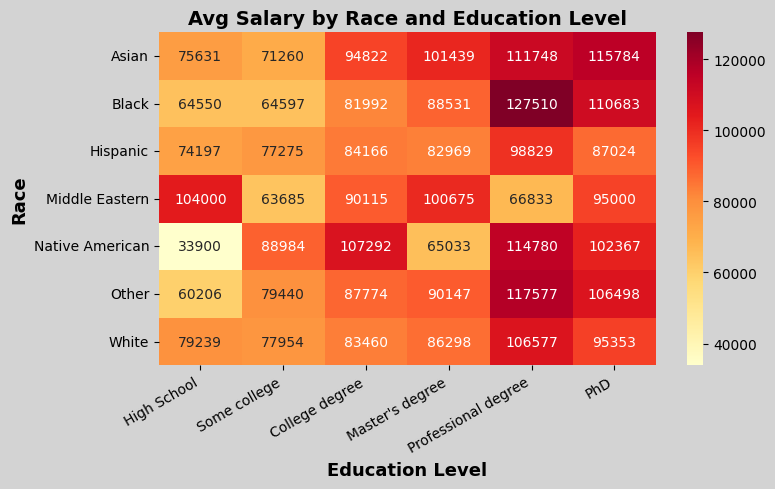

In [45]:
edu_order = ['High School', 'Some college', 'College degree', "Master's degree", 'Professional degree', 'PhD']

pivot = df.groupby(['race', 'highest_education'])['usd_salary'].mean().unstack('highest_education')[edu_order]

plt.figure(figsize=(8, 5), facecolor='lightgray')
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd')
plt.xlabel('Education Level', fontweight='bold', fontsize=13)
plt.ylabel('Race', fontweight='bold', fontsize=13)
plt.title('Avg Salary by Race and Education Level', fontweight='bold', fontsize=14)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
save_figure("salary_race_education_heatmap")
plt.show()